# Glabal land Temperature 

En este notebook se exploran algunas tecnicas para el preprocesamiento de los datos, en este caso los datos que tenemos son CSV, el cual nos da la temperatura promedio a lo largo del tiempo en varios lugares del mundo. 
Nos ayudamos de tecnicas como filtrado, algunas funciones para realizar la correcta visualización de datos.

## Carga de datos 

In [19]:
import pandas as pd
df = pd.read_csv(r'GLT_filtrado.csv', encoding='utf-8')

## Exploración de datos

Usamos algunas funciones de pandas, y otras de python para poder hacer la exploración de los datos como el tipo de datos, los datos nulos, la media, la desviasión estándar, los mímimos o máximos, etc. 

In [20]:
print(type(df))

<class 'pandas.DataFrame'>


In [21]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 219575 entries, 0 to 219574
Data columns (total 7 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Date                           219575 non-null  str    
 1   AverageTemperature             191994 non-null  float64
 2   AverageTemperatureUncertainty  191994 non-null  float64
 3   City                           219575 non-null  str    
 4   Country                        219575 non-null  str    
 5   Latitude                       219575 non-null  str    
 6   Longitude                      219575 non-null  str    
dtypes: float64(2), str(5)
memory usage: 11.7 MB


In [22]:
df.describe()

,AverageTemperature,AverageTemperatureUncertainty
count,191994.000000,191994.000000
mean,19.074293,1.148474
std,11.705712,3.374958
min,-26.772000,0.049000
25%,13.399000,0.329000
50%,20.857000,0.549000
75%,26.112000,1.151000
max,88.007000,41.588600


In [23]:
df.dtypes

Date                                 str
AverageTemperature               float64
AverageTemperatureUncertainty    float64
City                                 str
Country                              str
Latitude                             str
Longitude                            str
dtype: object

In [24]:
df.isnull().sum()

Date                                 0
AverageTemperature               27581
AverageTemperatureUncertainty    27581
City                                 0
Country                              0
Latitude                             0
Longitude                            0
dtype: int64

## 3. Convierte la columna Date de texto a una fecha (datetime)

Aquí vamos a tener que manipular el tiempo así que podemos ayudarnos con una función que ayuda a referirnos a las fechas

In [25]:
df['Date'] = pd.to_datetime(df['Date'])
df['Year'] = df['Date'].dt.year
df

,Date,AverageTemperature,AverageTemperatureUncertainty,City,Country,Latitude,Longitude,Year
0,1849-01-01,26.704,1.435,Abidjan,Côte D'Ivoire,5.63N,3.23W,1849
1,1849-02-01,27.434,1.362,Abidjan,Côte D'Ivoire,5.63N,3.23W,1849
2,1849-03-01,NaN,NaN,Abidjan,Côte D'Ivoire,5.63N,3.23W,1849
3,1849-04-01,26.140,1.387,Abidjan,Côte D'Ivoire,5.63N,3.23W,1849
4,1849-05-01,25.427,1.200,Abidjan,Côte D'Ivoire,5.63N,3.23W,1849
...,...,...,...,...,...,...,...,...
219570,2012-08-01,23.885,0.435,Xian,China,34.56N,108.97E,2012
219571,2012-09-01,17.028,1.405,Xian,China,34.56N,108.97E,2012
219572,2012-10-01,12.399,0.526,Xian,China,34.56N,108.97E,2012
219573,2012-11-01,4.736,0.519,Xian,China,34.56N,108.97E,2012


## 4. Filtra una ciudad

Quizás tengamos que aplicar un filtro, así que vamos a usar una función 

In [35]:
ciudad = 'Mexico'
d = df[df['City'] == "Mexico"]
print("Filas:", len(d))
d

Filas: 2136


,Date,AverageTemperature,AverageTemperatureUncertainty,City,Country,Latitude,Longitude,Year
135993,1835-01-01,13.086,1.942,Mexico,Mexico,20.09N,98.96W,1835
135994,1835-02-01,12.322,2.020,Mexico,Mexico,20.09N,98.96W,1835
135995,1835-03-01,13.874,2.271,Mexico,Mexico,20.09N,98.96W,1835
135996,1835-04-01,16.312,2.247,Mexico,Mexico,20.09N,98.96W,1835
135997,1835-05-01,NaN,NaN,Mexico,Mexico,20.09N,98.96W,1835
...,...,...,...,...,...,...,...,...
138124,2012-08-01,17.764,0.446,Mexico,Mexico,20.09N,98.96W,2012
138125,2012-09-01,17.374,0.364,Mexico,Mexico,20.09N,98.96W,2012
138126,2012-10-01,16.844,0.452,Mexico,Mexico,20.09N,98.96W,2012
138127,2012-11-01,14.009,0.330,Mexico,Mexico,20.09N,98.96W,2012


## 5. Calcula la temperatura media anual:

Vamos a calcular la media anual dado el filtro, pero para ello necesitamos conocer algunas funciones de pandas, como poder realizarnos nosotros mismos

In [34]:
for i in d["Year"].unique():
  data_for_year_i = d[d['Year'] == i]
  print(data_for_year_i['AverageTemperature'].mean())

25.522799999999997
25.47318181818182
25.504444444444445
nan
nan
nan
nan
26.7266
24.945125
25.48675
25.897727272727273
25.347222222222225
25.6718
25.173499999999997
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
25.751285714285718
25.681818181818176
25.419555555555558
24.9472
25.6238
25.87433333333334
25.383999999999997
25.81554545454546
25.92581818181818
25.68716666666667
26.137363636363638
26.366625
26.0685
25.474166666666665
24.91175
25.227600000000002
25.61311111111111
24.756818181818186
24.9188
25.205222222222226
25.330916666666667
25.18827272727273
25.345100000000006
25.143
25.642166666666668
25.404818181818186
26.552818181818182
26.203818181818182
25.918545454545452
25.62609090909091
25.4617
25.23691666666667
25.912454545454548
26.0103
25.63109090909091
25.629875000000002
25.71490909090909
25.75609090909091
25.363599999999998
26.44727272727273
26.436
26.3639
26.2523
26.192545454545453
26.47333333333334
25.932666666666666
26.192583333333335
26.47490909090909
26.3262
26.134500000000003
25

In [36]:
media_anual = d.groupby('Year')['AverageTemperature'].mean()
print(media_anual)

Year
1835    13.847818
1836    15.465200
1837    14.822583
1838    14.480333
1839    14.575444
          ...    
2008    16.469091
2009    16.704556
2010    16.009100
2011    16.613455
2012    16.426500
Name: AverageTemperature, Length: 178, dtype: float64



## 6. Grafica el resultado:

Siempre es importante gráficar los datos para ver como fue nuestro proceso, o como va la tendencia.

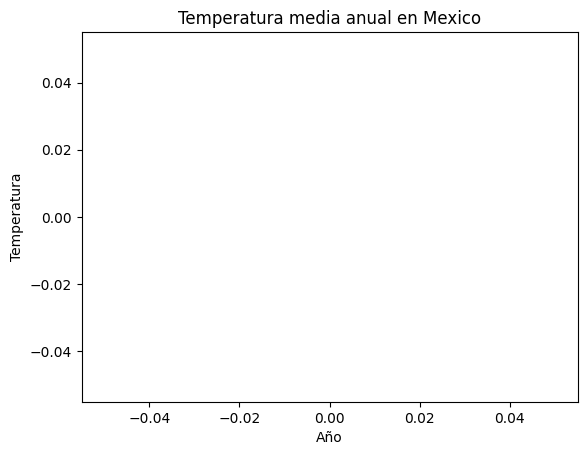

In [29]:
import matplotlib.pyplot as plt
plt.figure()
plt.plot(media_anual.index, media_anual.values, marker='o')
plt.plot()
plt.title(f'Temperatura media anual en Mexico')
plt.xlabel('Año')
plt.ylabel('Temperatura')
plt.show()

In [30]:
media_anual = d.groupby('Year')['AverageTemperature'].mean().dropna()
X = media_anual.index.values.reshape(-1, 1)
y = media_anual.values
X_norm = (X - X.min()) / (X.max() - X.min())

ValueError: zero-size array to reduction operation minimum which has no identity

Text(0, 0.5, 'Frencuencia')

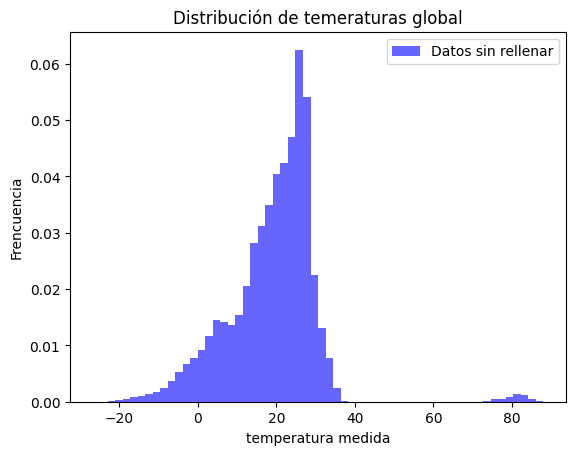

In [ ]:
plt.hist(df["AverageTemperature"], density=True, bins=60 , alpha=0.6, color="blue", label = "Datos sin rellenar")
plt.legend(loc = "best")
plt.title("Distribución de temeraturas global")
plt.xlabel("temperatura medida")
plt.ylabel("Frencuencia")